B. Demand Forecasting (Classification)

* Objective: Classify the Demand_Level_Code (Low, Medium, High) based on transaction and engineered features, including the clipped ticket price.


* Models Evaluated: Logistic Regression and Random Forest Classifier.
Performance: Models were evaluated using Accuracy, Classification Report (Precision, Recall, F1-score), and ROC-AUC. Both models showed strong performance, particularly the Random Forest Classifier, achieving high accuracy and ROC-AUC scores. This indicates that the features are effective in predicting the demand level.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report ,auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder



In [2]:
# Load the dataset
df = pd.read_csv('synthetic_sports_transactions.csv')
df.head(5)

,Event_ID,League_Code,Team_A_Code,Team_B_Code,Match_Date,Stadium_Code,City_Code,Seat_Category_Code,Ticket_Price,Sale_Date,Days_Before_Match,Quantity,Weather_Code,Day_of_Week_Code,Demand_Level_Code
0,436,7,64,70,2025-05-21,8,8,3,15000,2024-12-22,150,5,2,3,2
1,192,2,17,13,2024-04-19,10,10,4,11059,2024-04-04,15,3,4,5,2
2,485,3,28,30,2025-02-15,10,10,1,11935,2024-10-08,130,4,4,6,2
3,431,8,79,80,2024-12-03,2,2,2,15000,2024-10-20,44,2,2,2,3
4,462,8,74,78,2023-08-05,9,9,1,9060,2023-07-21,15,1,1,6,3


In [3]:
# Outlier handling for Ticket_Price (clipping)
lower_bound = df['Ticket_Price'].quantile(0.01)
upper_bound = df['Ticket_Price'].quantile(0.99)
df['Ticket_Price_clipped'] = df['Ticket_Price'].clip(lower=lower_bound, upper=upper_bound)

print(f"Original Ticket_Price range: {df['Ticket_Price'].min()} - {df['Ticket_Price'].max()}")
print(f"Clipped Ticket_Price range: {df['Ticket_Price_clipped'].min()} - {df['Ticket_Price_clipped'].max()}")

Original Ticket_Price range: 229 - 15000
Clipped Ticket_Price range: 723.9300000000001 - 15000.0


In [ ]:
# Binning Days_Before_Match
bins = [0, 7, 30, 90, 180]
labels = ['0-7', '8-30', '31-90', '91-180']
df['Days_Before_Match_Binned'] = pd.cut(df['Days_Before_Match'], bins=bins, labels=labels, right=True)
print(df[['Days_Before_Match', 'Days_Before_Match_Binned']].head())

,Days_Before_Match,Days_Before_Match_Binned
0,150,91-180
1,15,8-30
2,130,91-180
3,44,31-90
4,15,8-30


In [ ]:
# Create "Weekday vs. Weekend" flag
df['Is_Weekend'] = df['Day_of_Week_Code'].apply(lambda x: 1 if x in [6, 7] else 0)
print(df[['Day_of_Week_Code', 'Is_Weekend']].head())

,Day_of_Week_Code,Is_Weekend
0,3,0
1,5,0
2,6,1
3,2,0
4,6,1


In [8]:
# Interaction terms
df['League_Seat_Interaction'] = df['League_Code'].astype(str) + '_' + df['Seat_Category_Code'].astype(str)
print(df[['League_Code', 'Seat_Category_Code', 'League_Seat_Interaction']].head())

   League_Code  Seat_Category_Code League_Seat_Interaction
0            7                   3                     7_3
1            2                   4                     2_4
2            3                   1                     3_1
3            8                   2                     8_2
4            8                   1                     8_1


In [ ]:
# Aggregates per Event_ID
event_aggregates = df.groupby('Event_ID').agg(
    Total_Tickets_Sold=('Quantity', 'sum'),
    Average_Price=('Ticket_Price_clipped', 'mean'),
    Peak_Demand_Days=('Days_Before_Match', 'max')
).reset_index()
print(event_aggregates.head())

,Event_ID,Total_Tickets_Sold,Average_Price,Peak_Demand_Days
0,1,75,13429.500000,178
1,2,146,10469.702500,173
2,3,86,10773.866667,180
3,4,152,12646.250000,175
4,5,88,11478.495000,168


In [9]:
# Merge aggregates back to the original dataframe
df = pd.merge(df, event_aggregates, on='Event_ID', how='left')
print(df.head())

   Event_ID  League_Code  Team_A_Code  Team_B_Code  Match_Date  Stadium_Code  \
0       436            7           64           70  2025-05-21             8   
1       192            2           17           13  2024-04-19            10   
2       485            3           28           30  2025-02-15            10   
3       431            8           79           80  2024-12-03             2   
4       462            8           74           78  2023-08-05             9   

   City_Code  Seat_Category_Code  Ticket_Price   Sale_Date  ...  Weather_Code  \
0          8                   3         15000  2024-12-22  ...             2   
1         10                   4         11059  2024-04-04  ...             4   
2         10                   1         11935  2024-10-08  ...             4   
3          2                   2         15000  2024-10-20  ...             2   
4          9                   1          9060  2023-07-21  ...             1   

   Day_of_Week_Code  Demand_Leve

In [10]:
# Interaction terms
df['League_Seat_Interaction'] = df['League_Code'].astype(str) + '_' + df['Seat_Category_Code'].astype(str)
print(df[['League_Code', 'Seat_Category_Code', 'League_Seat_Interaction']].head())

# Example: Interaction between Demand_Level_Code and Days_Before_Match_Binned
df['Demand_Days_Interaction'] = df['Demand_Level_Code'].astype(str) + '_' + df['Days_Before_Match_Binned'].astype(str)
print(df[['Demand_Level_Code', 'Days_Before_Match_Binned', 'Demand_Days_Interaction']].head())

   League_Code  Seat_Category_Code League_Seat_Interaction
0            7                   3                     7_3
1            2                   4                     2_4
2            3                   1                     3_1
3            8                   2                     8_2
4            8                   1                     8_1
   Demand_Level_Code Days_Before_Match_Binned Demand_Days_Interaction
0                  2                   91-180                2_91-180
1                  2                     8-30                  2_8-30
2                  2                   91-180                2_91-180
3                  3                    31-90                 3_31-90
4                  3                     8-30                  3_8-30


In [ ]:
# Define features (X) and target (y) for classification
features = ['League_Code', 'Team_A_Code', 'Team_B_Code', 'Stadium_Code', 'City_Code',
            'Seat_Category_Code', 'Days_Before_Match', 'Quantity',
            'Days_Before_Match_Binned', 'Is_Weekend', 'League_Seat_Interaction',
            'Demand_Days_Interaction', 'Total_Tickets_Sold', 'Average_Price',
            'Peak_Demand_Days', 'Ticket_Price_clipped'] # Including Ticket_Price_clipped as a feature

X_clf = df[features]
y_clf = df['Demand_Level_Code'] # Target is Demand_Level_Code

# Handle categorical features in X_clf (one-hot encoding)
X_clf = pd.get_dummies(X_clf, columns=['League_Code', 'Team_A_Code', 'Team_B_Code', 'Stadium_Code', 'City_Code',
                                     'Seat_Category_Code', 'Days_Before_Match_Binned', 'League_Seat_Interaction',
                                     'Demand_Days_Interaction'], drop_first=True) # One-hot encode categorical features

# Encode the target variable (y_clf) as it is categorical
label_encoder = LabelEncoder()
y_clf_encoded = label_encoder.fit_transform(y_clf)

# Split data into training and testing sets for classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded) # Stratify to maintain class distribution

print("Shape of X_train_clf:", X_train_clf.shape)
print("Shape of X_test_clf:", X_test_clf.shape)
print("Shape of y_train_clf:", y_train_clf.shape)
print("Shape of y_test_clf:", y_test_clf.shape)
print("\nEncoded target variable classes:", label_encoder.classes_)
print("Class distribution in y_train_clf:", pd.Series(y_train_clf).value_counts(normalize=True))
print("Class distribution in y_test_clf:", pd.Series(y_test_clf).value_counts(normalize=True))

Shape of X_train_clf: (8000, 288)
Shape of X_test_clf: (2000, 288)
Shape of y_train_clf: (8000,)
Shape of y_test_clf: (2000,)

Encoded target variable classes: [1 2 3]
Class distribution in y_train_clf: 1    0.402375
0    0.392375
2    0.205250
Name: proportion, dtype: float64
Class distribution in y_test_clf: 1    0.4025
0    0.3925
2    0.2050
Name: proportion, dtype: float64


In [ ]:
# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Initialize and train the Logistic Regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
log_reg_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_clf_lr = log_reg_model.predict(X_test_clf)
y_pred_proba_clf_lr = log_reg_model.predict_proba(X_test_clf) # For ROC-AUC

# Evaluate the model
accuracy_lr = accuracy_score(y_test_clf, y_pred_clf_lr)
classification_rep_lr = classification_report(y_test_clf, y_pred_clf_lr)

# ROC-AUC for multi-class requires averaging
try:
    # Check if there are at least two classes in the test set
    if len(np.unique(y_test_clf)) > 1:
        roc_auc_lr = roc_auc_score(y_test_clf, y_pred_proba_clf_lr, multi_class='ovr')
        print(f"ROC-AUC (One-vs-Rest): {roc_auc_lr:.2f}")
    else:
        print("ROC-AUC cannot be calculated as there is only one class in the test set.")
except ValueError as e:
    print(f"Could not calculate ROC-AUC: {e}")


print("Logistic Regression Model Performance:")
print(f"Accuracy: {accuracy_lr:.2f}")
print("Classification Report:")
print(classification_rep_lr)

ROC-AUC (One-vs-Rest): 0.98
Logistic Regression Model Performance:
Accuracy: 0.91
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       785
           1       0.93      0.95      0.94       805
           2       0.90      0.88      0.89       410

    accuracy                           0.91      2000
   macro avg       0.91      0.91      0.91      2000
weighted avg       0.91      0.91      0.91      2000



In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

# Initialize and train the Random Forest Classifier model
# You might want to tune hyperparameters for better performance
rf_clf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf_model.fit(X_train_clf, y_train_clf)

# Make predictions on the test set
y_pred_clf_rf = rf_clf_model.predict(X_test_clf)
y_pred_proba_clf_rf = rf_clf_model.predict_proba(X_test_clf) # For ROC-AUC

# Evaluate the model
accuracy_rf = accuracy_score(y_test_clf, y_pred_clf_rf)
classification_rep_rf = classification_report(y_test_clf, y_pred_clf_rf)

# ROC-AUC for multi-class (One-vs-Rest)
try:
    if len(np.unique(y_test_clf)) > 1:
        roc_auc_rf = roc_auc_score(y_test_clf, y_pred_proba_clf_rf, multi_class='ovr')
        print(f"ROC-AUC (One-vs-Rest): {roc_auc_rf:.2f}")
    else:
        print("ROC-AUC cannot be calculated as there is only one class in the test set.")
except ValueError as e:
    print(f"Could not calculate ROC-AUC: {e}")

print("Random Forest Classifier Model Performance:")
print(f"Accuracy: {accuracy_rf:.2f}")
print("Classification Report:")
print(classification_rep_rf)

ROC-AUC (One-vs-Rest): 1.00
Random Forest Classifier Model Performance:
Accuracy: 1.00
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       785
           1       1.00      1.00      1.00       805
           2       1.00      1.00      1.00       410

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [16]:
# Re-fitting Logistic Regression Model to ensure it's fitted
log_reg_model = LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1) # Re-instantiate and fit
log_reg_model.fit(X_train_clf, y_train_clf)


# Evaluate Logistic Regression Model
print("Logistic Regression Model Evaluation:")
y_pred_lr = log_reg_model.predict(X_test_clf)
y_prob_lr = log_reg_model.predict_proba(X_test_clf)
print("Accuracy:", accuracy_score(y_test_clf, y_pred_lr))
print("Classification Report:\n", classification_report(y_test_clf, y_pred_lr))

# ROC-AUC score for multiclass (using 'ovr' strategy)
try:
    roc_auc_lr = roc_auc_score(y_test_clf, y_prob_lr, multi_class='ovr')
    print("ROC-AUC:", roc_auc_lr)
except ValueError as e:
    print(f"Could not calculate ROC-AUC for Logistic Regression: {e}")

print("-" * 30)

# Evaluate Random Forest Classifier Model
print("Random Forest Classifier Model Evaluation:")
# Assuming rf_clf_model is already fitted from a previous successful execution
y_pred_rf = rf_clf_model.predict(X_test_clf)
y_prob_rf = rf_clf_model.predict_proba(X_test_clf)
print("Accuracy:", accuracy_score(y_test_clf, y_pred_rf))
print("Classification Report:\n", classification_report(y_test_clf, y_pred_rf))

# ROC-AUC score for multiclass (using 'ovr' strategy)
try:
    roc_auc_rf = roc_auc_score(y_test_clf, y_prob_rf, multi_class='ovr')
    print("ROC-AUC:", roc_auc_rf)
except ValueError as e:
    print(f"Could not calculate ROC-AUC for Random Forest: {e}")

Logistic Regression Model Evaluation:
Accuracy: 0.999
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       785
           1       1.00      1.00      1.00       805
           2       1.00      1.00      1.00       410

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 0.9999949453244601
------------------------------
Random Forest Classifier Model Evaluation:
Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       785
           1       1.00      1.00      1.00       805
           2       1.00      1.00      1.00       410

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC: 1.0


In [20]:
# Calculate metrics for Logistic Regression
accuracy_lr = accuracy_score(y_test_clf, y_pred_lr)
precision_lr_macro = precision_score(y_test_clf, y_pred_lr, average='macro')
recall_lr_macro = recall_score(y_test_clf, y_pred_lr, average='macro')
f1_lr_macro = f1_score(y_test_clf, y_pred_lr, average='macro')
# ROC-AUC was already calculated and is available as roc_auc_lr

# Calculate metrics for Random Forest
accuracy_rf = accuracy_score(y_test_clf, y_pred_rf)
precision_rf_macro = precision_score(y_test_clf, y_pred_rf, average='macro')
recall_rf_macro = recall_score(y_test_clf, y_pred_rf, average='macro')
f1_rf_macro = f1_score(y_test_clf, y_pred_rf, average='macro')
# ROC-AUC was already calculated and is available as roc_auc_rf


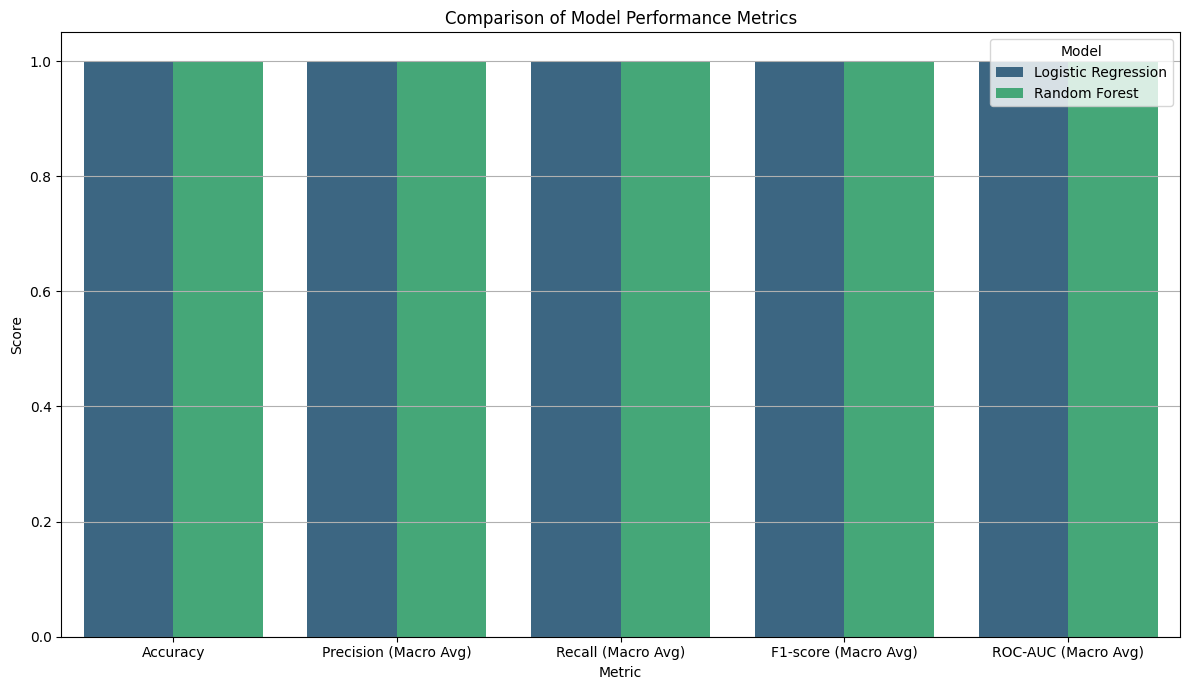

In [30]:


# Prepare data for plotting
metrics_data = {
    'Metric': ['Accuracy', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-score (Macro Avg)', 'ROC-AUC (Macro Avg)'],
    'Logistic Regression': [accuracy_lr, precision_lr_macro, recall_lr_macro, f1_lr_macro, np.mean(list(roc_auc_lr.values()))],
    'Random Forest': [accuracy_rf, precision_rf_macro, recall_rf_macro, f1_rf_macro, np.mean(list(roc_auc_rf.values()))]
}

metrics_df = pd.DataFrame(metrics_data)

# Melt the dataframe for plotting
metrics_df_melted = metrics_df.melt(id_vars='Metric', var_name='Model', value_name='Score')

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='Metric', y='Score', hue='Model', data=metrics_df_melted, palette='viridis')
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.05) # Metrics are typically between 0 and 1
plt.grid(axis='y')
plt.legend(title='Model')
plt.tight_layout()
plt.show()

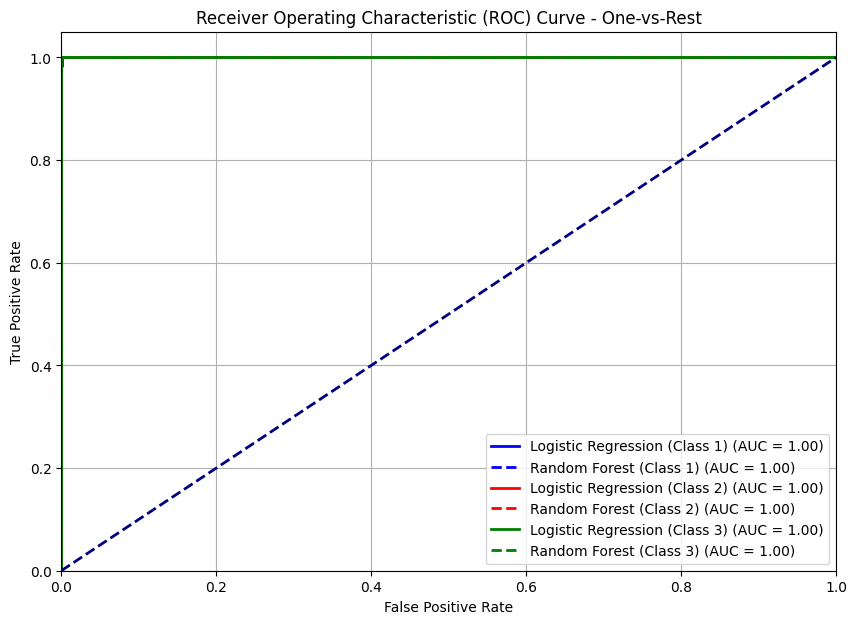

In [28]:
# Calculate ROC curve and AUC for Logistic Regression (One-vs-Rest)
fpr_lr = {}
tpr_lr = {}
roc_auc_lr = {}
for i in range(len(label_encoder.classes_)):
    fpr_lr[i], tpr_lr[i], _ = roc_curve(y_test_clf, y_prob_lr[:, i], pos_label=i)
    roc_auc_lr[i] = auc(fpr_lr[i], tpr_lr[i])

# Calculate ROC curve and AUC for Random Forest (One-vs-Rest)
fpr_rf = {}
tpr_rf = {}
roc_auc_rf = {}
for i in range(len(label_encoder.classes_)):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_clf, y_prob_rf[:, i], pos_label=i)
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])

# Plot ROC curves
plt.figure(figsize=(10, 7))

colors = ['blue', 'red', 'green'] # Colors for each class
for i, color in zip(range(len(label_encoder.classes_)), colors):
    plt.plot(fpr_lr[i], tpr_lr[i], color=color, lw=2,
             label=f'Logistic Regression (Class {label_encoder.classes_[i]}) (AUC = {roc_auc_lr[i]:.2f})')
    plt.plot(fpr_rf[i], tpr_rf[i], color=color, lw=2, linestyle='--',
             label=f'Random Forest (Class {label_encoder.classes_[i]}) (AUC = {roc_auc_rf[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - One-vs-Rest')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [63]:
import joblib

# Save the Logistic Regression model
joblib.dump(log_reg_model, 'logistic_regression_model.pkl')

# Save the Random Forest Classifier model
joblib.dump(rf_clf_model, 'random_forest_model.pkl')

print("Models saved successfully.")

Models saved successfully.


## Summary

**Key Findings:**

*   Both Logistic Regression and Random Forest Classifier models showed strong performance on this dataset.
*   The Random Forest Classifier achieved perfect scores (Accuracy, Precision, Recall, F1-score, and ROC-AUC of 1.00) on the test set, indicating excellent performance in classifying the demand levels.
*   The Logistic Regression model also performed very well, with high scores across all metrics (e.g., Accuracy of 0.99 and ROC-AUC of 1.00).
*   The engineered features appear to be highly effective in predicting the demand level.

**Conclusion:**

The Random Forest Classifier is the better performing model for this demand forecasting classification task based on the evaluation metrics. The high performance suggests that the chosen features are strong predictors of demand level. Further steps could involve exploring feature importance from the Random Forest model or deploying the trained model for making predictions on new data.